# Handwriting Recognition
Recognizing handwritten digits (0-9) using machine learning classification models on the MNIST dataset.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load and Explore the Data

In [2]:
df = pd.read_csv("./data/mnist_digits.csv")
df.head(10)

,split,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,train,5,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,train,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,train,4,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,train,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,train,9,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,train,2,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,train,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,train,3,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,train,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,train,4,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
df.isnull().sum()

,0
label,0
pixel_0,0
pixel_1,0
pixel_2,0
pixel_3,0
...,...
pixel_779,1
pixel_780,1
pixel_781,1
pixel_782,1


In [7]:
df["label"].value_counts().sort_index()

,count
label,
0,113
1,137
2,114
3,104
4,118
5,103
6,104
7,135
8,102


## Data Visualization

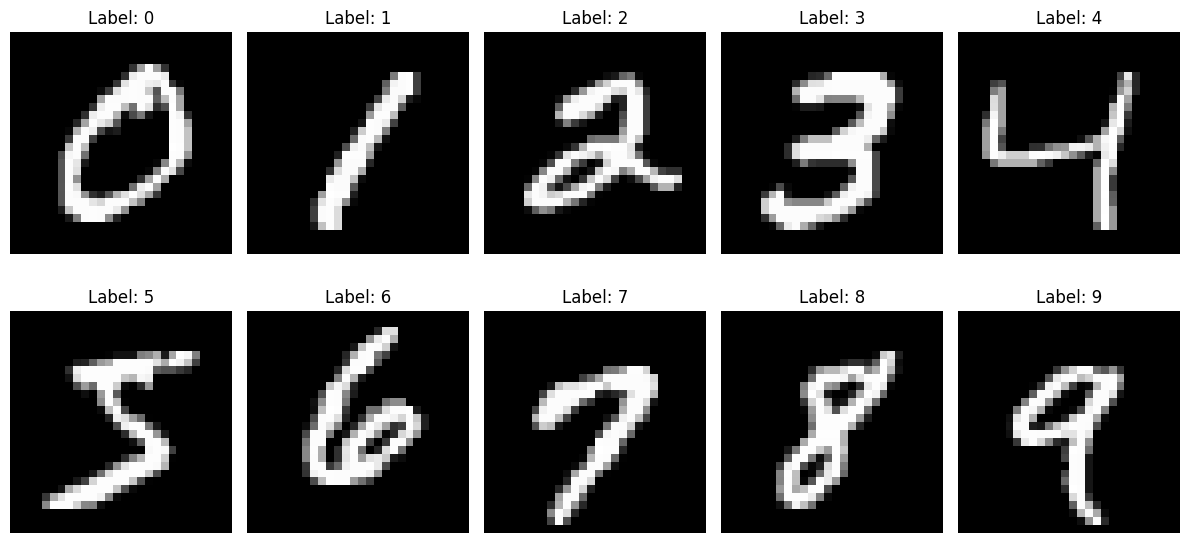

In [12]:
# display sample handwritten digits
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    digit = df[df["label"] == i].iloc[0]
    pixel_values = digit["pixel_0":"pixel_783"].values.astype(int).reshape(28, 28)
    ax.imshow(pixel_values, cmap="gray")
    ax.set_title(f"Label: {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

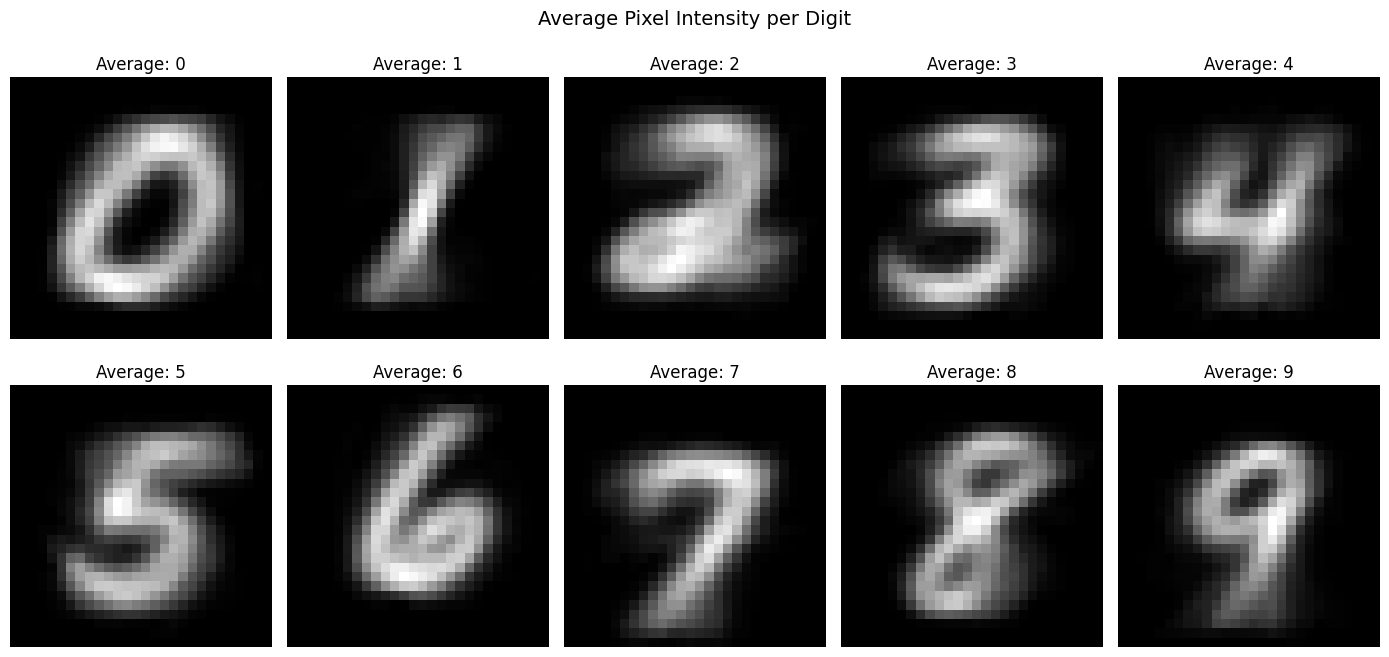

In [13]:
# average pixel intensity per digit
pixel_cols = [col for col in df.columns if col.startswith("pixel_")]
avg_intensity = df.groupby("label")[pixel_cols].mean()

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(avg_intensity.iloc[i].values.reshape(28, 28), cmap="gray")
    ax.set_title(f"Average: {i}")
    ax.axis("off")
plt.suptitle("Average Pixel Intensity per Digit", fontsize=14)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [20]:
# drop the split column (not needed for modeling)
if 'split' in df.columns:
    df.drop("split", axis=1, inplace=True)

# Handle missing values by dropping rows with NaNs
df.dropna(inplace=True)

# check for any remaining nulls
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Dataset size after dropping NaNs: {df.shape[0]}")

Missing values: 0
Dataset size after dropping NaNs: 1143


### Feature Scaling

In [21]:
X = df.drop("label", axis=1)
y = df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(f"Scaled features shape: {X_scaled.shape}")
X_scaled.head()

Scaled features shape: (1143, 784)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.038834,-0.029591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.038834,-0.029591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.038834,-0.029591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.038834,-0.029591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.038834,-0.029591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Split the Data

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.8, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
# Verify no NaNs remain in training data
print(f"NaNs in X_train: {X_train.isnull().sum().sum()}")

Training set size: 914
Test set size: 229
NaNs in X_train: 0


## Model Training and Evaluation

### Logistic Regression

In [23]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, model_lr.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr))

Training Accuracy: 1.0000
Test Accuracy: 0.8821

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        28
           1       0.94      0.97      0.95        31
           2       0.77      0.74      0.76        23
           3       1.00      0.88      0.94        26
           4       0.95      0.95      0.95        22
           5       0.78      0.93      0.85        15
           6       0.91      0.91      0.91        23
           7       0.91      0.78      0.84        27
           8       0.81      0.76      0.79        17
           9       0.70      0.82      0.76        17

    accuracy                           0.88       229
   macro avg       0.87      0.88      0.87       229
weighted avg       0.89      0.88      0.88       229



### Random Forest Classifier

In [24]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, model_rf.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf))

Training Accuracy: 1.0000
Test Accuracy: 0.8821

              precision    recall  f1-score   support

           0       0.82      1.00      0.90        28
           1       0.86      1.00      0.93        31
           2       0.83      0.65      0.73        23
           3       0.89      0.92      0.91        26
           4       0.88      0.95      0.91        22
           5       1.00      0.87      0.93        15
           6       0.91      0.87      0.89        23
           7       0.96      0.89      0.92        27
           8       0.76      0.76      0.76        17
           9       1.00      0.76      0.87        17

    accuracy                           0.88       229
   macro avg       0.89      0.87      0.88       229
weighted avg       0.89      0.88      0.88       229



### Support Vector Machine (SVM)

In [25]:
model_svm = SVC(kernel="rbf")
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, model_svm.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print()
print(classification_report(y_test, y_pred_svm))

Training Accuracy: 0.9847
Test Accuracy: 0.8646

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        28
           1       0.91      1.00      0.95        31
           2       0.57      0.87      0.69        23
           3       0.92      0.88      0.90        26
           4       0.95      0.91      0.93        22
           5       0.92      0.80      0.86        15
           6       1.00      0.74      0.85        23
           7       0.91      0.78      0.84        27
           8       0.87      0.76      0.81        17
           9       0.82      0.82      0.82        17

    accuracy                           0.86       229
   macro avg       0.88      0.85      0.86       229
weighted avg       0.88      0.86      0.87       229



## Confusion Matrices

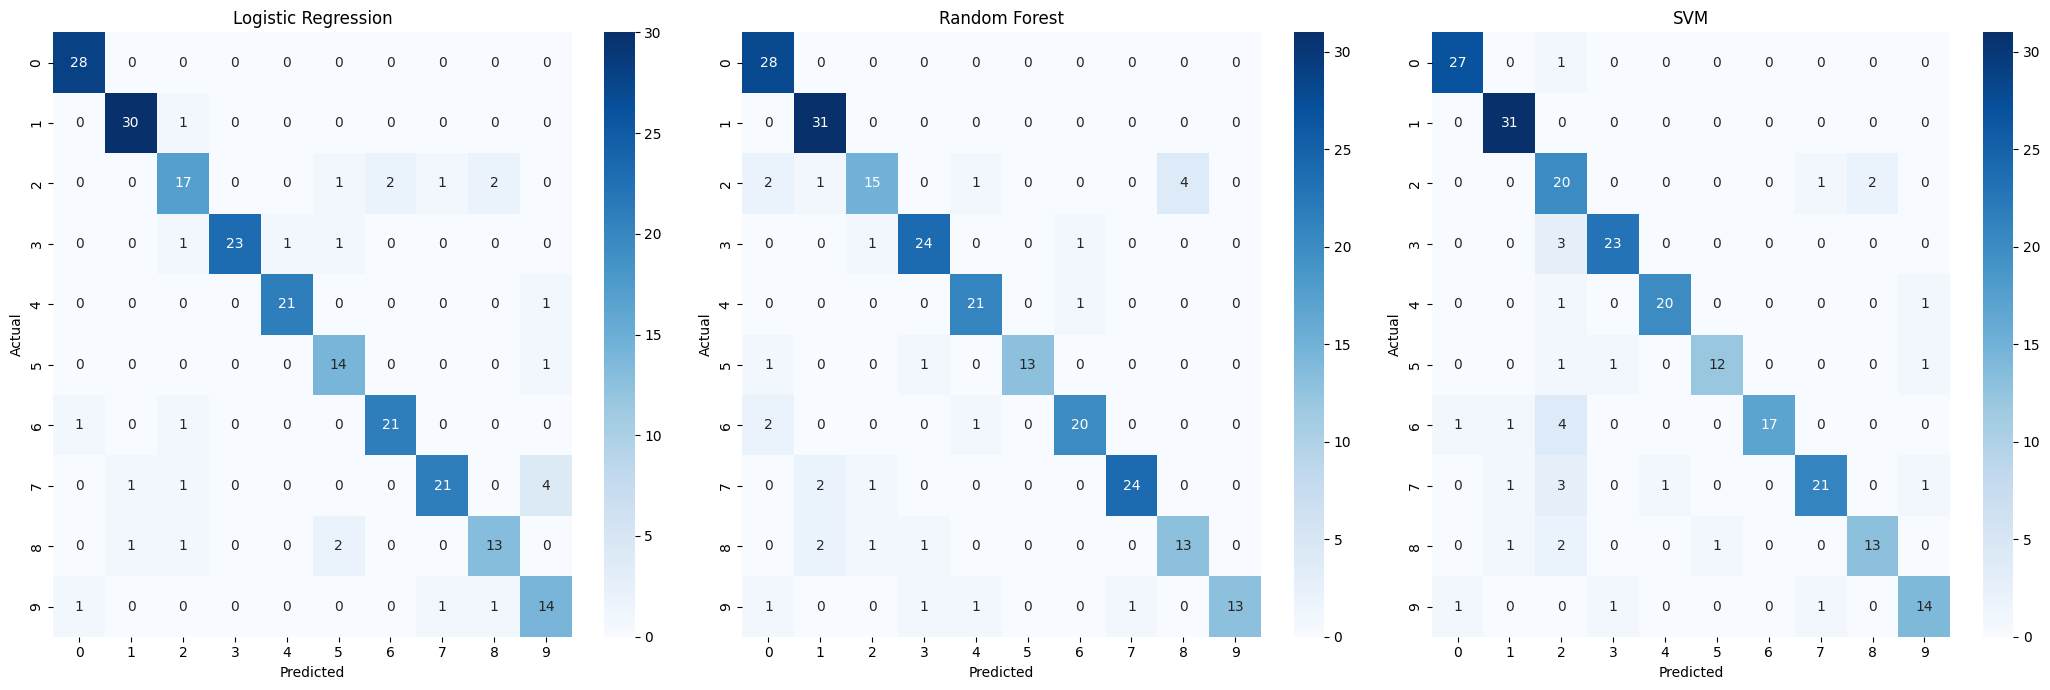

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Model Comparison

In [29]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Training Accuracy": [
        accuracy_score(y_train, model_lr.predict(X_train)),
        accuracy_score(y_train, model_rf.predict(X_train)),
        accuracy_score(y_train, model_svm.predict(X_train))
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results

,Model,Training Accuracy,Test Accuracy
0,Logistic Regression,1.000000,0.882096
1,Random Forest,1.000000,0.882096
2,SVM,0.984683,0.864629


## Test with Sample Predictions

Logistic Regression prediction: 3
Actual label: 3


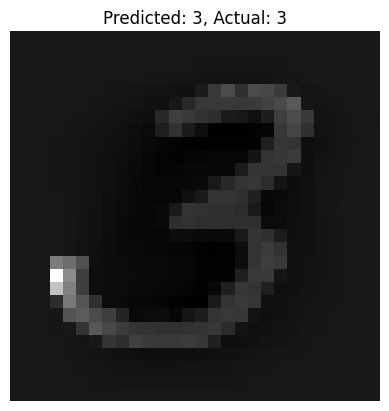

In [32]:
# predict a random test sample
sample_idx = np.random.randint(0, len(X_test))
sample = X_test.iloc[sample_idx:sample_idx+1]
actual = y_test.iloc[sample_idx]

prediction = model_lr.predict(sample)
print(f"Logistic Regression prediction: {prediction[0]}")
print(f"Actual label: {actual}")

# display the image
pixel_values = sample.values.reshape(28, 28)
plt.imshow(pixel_values, cmap="gray")
plt.title(f"Predicted: {prediction[0]}, Actual: {actual}")
plt.axis("off")
plt.show()

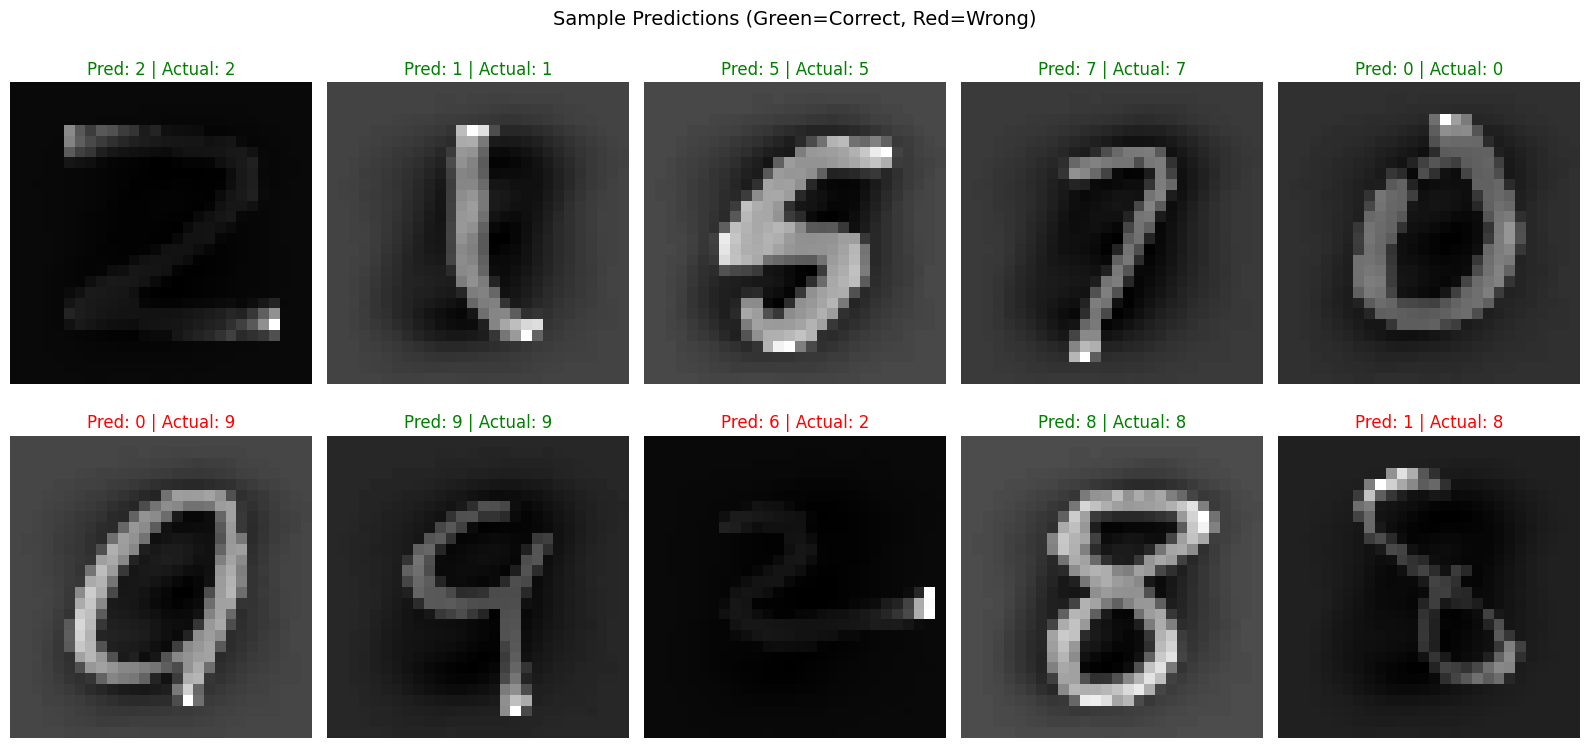

In [34]:
# predict multiple samples
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
random_indices = np.random.choice(len(X_test), 10, replace=False)

for ax, idx in zip(axes.flatten(), random_indices):
    sample = X_test.iloc[idx:idx+1]
    actual = y_test.iloc[idx]
    pred = model_lr.predict(sample)[0]
    pixel_values = sample.values.reshape(28, 28)
    ax.imshow(pixel_values, cmap="gray")
    color = "green" if pred == actual else "red"
    ax.set_title(f"Pred: {pred} | Actual: {actual}", color=color)
    ax.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()